In [1]:
import sys 
from pathlib import Path
import importlib 
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_raw_dataset
from utils.face_recognition import load_insightface_model, get_embeddings, allign_faces, FaceDetector
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt
import torch 
from tqdm import tqdm

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'

# IP-adapter

In [94]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image
from huggingface_hub import hf_hub_download
import cv2
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import torch
from thirdparty.ip_adapter.ip_adapter_faceid import IPAdapterFaceIDPlus


class IPAdapterAugmentor:
    def __init__(
            self,
            ck_images_alinged: np.ndarray,
            ck_embeds: np.ndarray | None = None,
            base_model_path: str = "SG161222/Realistic_Vision_V4.0_noVAE",
            vae_model_path: str = "stabilityai/sd-vae-ft-mse",
            image_encoder_path: str = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K",
            repo_id: str = "h94/IP-Adapter-FaceID",
            device: str = "cpu",
            v2: bool = False,
            seed: int = 2023,
            num_samples: int = 4,
            num_inference_steps: int = 30,
            width: int = 256,
            height: int = 256,
            s_scale: float = 5.0,
            prompt: str = "frontal portrait of a game character",
            negative_prompt: str = "side view",
            arcface_path: str = "../../thirdparty/recognition/weights/arcface_r100.pth",
    ):
        self.noise_scheduler = DDIMScheduler(
            num_train_timesteps=1000,
            beta_start=0.00085,
            beta_end=0.012,
            beta_schedule="scaled_linear",
            clip_sample=False,
            set_alpha_to_one=False,
            steps_offset=1,
        )
        self.vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float32)
        self.pipe = StableDiffusionPipeline.from_pretrained(
            base_model_path,
            torch_dtype=torch.float32,
            scheduler=self.noise_scheduler,
            vae=self.vae,
            feature_extractor=None,
            safety_checker=None
        )

        # load ip-adapter
        ip_ckpt = "ip-adapter-faceid-plus_sd15.bin" if not v2 else "ip-adapter-faceid-plusv2_sd15.bin"
        ckpt_path = hf_hub_download(repo_id=repo_id, filename=ip_ckpt)
        self.ip_model = IPAdapterFaceIDPlus(self.pipe, image_encoder_path, ckpt_path, device, torch_dtype=torch.float32)

        # load app 
        self.app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.app.prepare(ctx_id=0)

        self.seed = seed
        self.num_samples = num_samples
        self.num_inference_steps = num_inference_steps
        self.width = width
        self.height = height
        self.s_scale = s_scale
        self.prompt = prompt
        self.negative_prompt = negative_prompt
        self.v2 = v2

        self.ck_images_alinged = ck_images_alinged
        if ck_embeds is None:
            ck_embeds_arr = []
            for ck_image in ck_images_alinged:
                ck_embed = self.get_embed_from_alligned(ck_image)
                ck_embeds_arr.append(ck_embed)
            self.ck_embeds = torch.stack(ck_embeds_arr)
        else:
            self.ck_embeds = torch.tensor(ck_embeds)

        self.arcface = load_insightface_model(arcface_path)


    def get_embed_from_alligned(self, image):
        model = self.app.models["recognition"]
        emb = model.get_feat(image).flatten()
        return torch.tensor(emb)
    
    def get_embed(self, image):
        faces = self.app.get(image)
        faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        landmarks = faces[0].kps
        aligned = face_align.norm_crop(image, landmark=landmarks, image_size=112)
        return faceid_embeds, aligned
    
    def get_embed_arcface_r100(self, alligned_image):
        return torch.tensor(get_embeddings(alligned_image[None], self.arcface))

    def get_closest_ck(self, real_image: np.ndarray) -> np.ndarray:
        real_embed = self.get_embed_arcface_r100(real_image)
        distances = torch.nn.CosineSimilarity(dim=1, eps=1e-6)(self.ck_embeds, real_embed)
        closest_index = torch.argmax(distances)
        return np.array(Image.open(self.ck_images_alinged[closest_index]))

    def make_real_closer_to_ck(self, real_image: np.ndarray, ck_image_aligned: np.ndarray | None = None) -> np.ndarray:
        real_embed, real_aligned = self.get_embed(real_image)
        if ck_image_aligned is None:
            ck_image_aligned = self.get_closest_ck(real_aligned)

        images = self.ip_model.generate(
            prompt=self.prompt, negative_prompt=self.negative_prompt, face_image=ck_image_aligned, faceid_embeds=real_embed, shortcut=self.v2, s_scale=self.s_scale,
            num_samples=self.num_samples, width=self.width, height=self.height, num_inference_steps=self.num_inference_steps, seed=self.seed
        )

        return images
    
def make_images_closer_to_ck(images, ck_images_paths, ck_embeds, checkpoint_path: Path = None):
    prompt = "The image presents a highly detailed and realistic video game avatar / digital rendering in a portrait view with smooth textures and soft, natural lighting that adds depth. The subject, a bald male, is depicted in a front-facing pose, with the entire face, neck, and upperchest clearly visible. The face is centrally positioned, with the eyes aligned near the upper third."
    augmentor = IPAdapterAugmentor(
        ck_images_alinged=ck_images_paths, 
        ck_embeds=ck_embeds, s_scale=1.3, v2=True,
        prompt=prompt,
        num_samples=5,
    )
    if checkpoint_path is not None:
        checkpoint_path.resolve().parent.mkdir(exist_ok=True, parents=True)

    augmented_images = []
    for i, image in tqdm(list(enumerate(images))):
        if i % 20 == 1 and checkpoint_path is not None:
            np.save(checkpoint_path / f"checkpoint_{i}", np.array(augmented_images))
        augmented = augmentor.make_real_closer_to_ck(image)
        augmented_images.append(augmented)
    return np.array(augmented_images)

In [22]:
celeba_dataset = ProcessedDataset(DATA_DIR / "celeba_sample_embeddings")
celeba_attrs = pd.read_csv("/Users/czyjtu/Downloads/archive/list_attr_celeba.csv")
# select 200 images of male 
male_paths = [p for p in celeba_dataset.paths if celeba_attrs.loc[celeba_attrs["image_id"] == Path(p).name]["Male"].values[0] == 1][:200]
print(len(male_paths))
celeba_images = np.array([np.array(Image.open(p)) for p in male_paths])

medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
out_dir = DATA_DIR / "celeba_ck_images"
out_dir.mkdir(exist_ok=True)
np.save(out_dir / "celeba_images", celeba_images)
celeba_ck_images = make_images_closer_to_ck(celeba_images, medium_geneset.paths, medium_geneset.model2embeddings["arcface-r100"], checkpoint_path=out_dir)
np.save(out_dir / "celeba_ck_images", celeba_ck_images)

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 12.28it/s]
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
100%|██████████| 30/30 [01:59<00:00,  3.97s/it]


# Brudnopis 

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


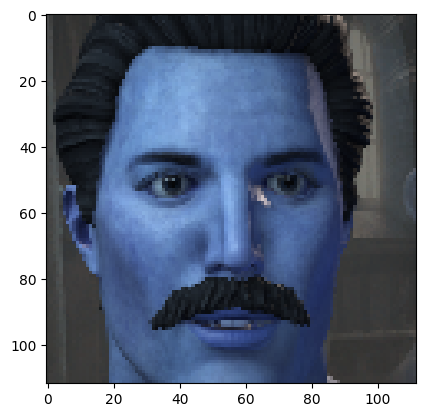

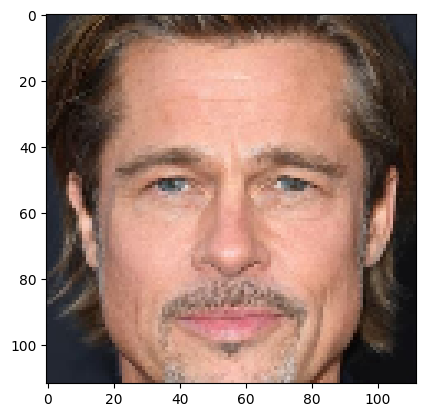

In [3]:
import cv2
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0)
print(app.models.items())

ck_image = cv2.imread("../../data/ck_faces_dataset/freddie_mercury/freddie_mercury.png")
real_image = cv2.imread("../../data/real_faces_dataset/brad_pit/006_aee8d88b.jpg")

def get_embed(app, image):
    faces = app.get(image)
    faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
    landmarks = faces[0].kps
    aligned = face_align.norm_crop(image, landmark=landmarks, image_size=112)
    return faceid_embeds, aligned

def get_embed_from_alligned(app, image):
    model = app.models["recognition"]
    emb = model.get_feat(image).flatten()
    return torch.tensor(emb), image

# ck_aligned = allign_faces(np.array(ck_image)[None, :], FaceDetector(), [""], None)[0][0]
# print(ck_aligned.shape)
ck_embed, ck_aligned = get_embed(app, ck_image)#get_embed_from_alligned(app, easy_geneset.alligned_images[np.random.randint(0, len(easy_geneset.alligned_images))])
real_embed, real_aligned = get_embed(app, real_image)

plt.imshow(ck_aligned)
plt.show()
plt.imshow(cv2.cvtColor(real_aligned, cv2.COLOR_BGR2RGB))
plt.show()


In [128]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image
from huggingface_hub import hf_hub_download

from thirdparty.ip_adapter.ip_adapter_faceid import IPAdapterFaceIDPlus

v2 = False
base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
image_encoder_path = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"
repo_id = "h94/IP-Adapter-FaceID"
ip_ckpt = "ip-adapter-faceid-plus_sd15.bin" if not v2 else "ip-adapter-faceid-plusv2_sd15.bin"
device = "cpu"
ckpt_path = hf_hub_download(repo_id=repo_id, filename=ip_ckpt)

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)
vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float32)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float32,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None
)

# load ip-adapter
ip_model = IPAdapterFaceIDPlus(pipe, image_encoder_path, ckpt_path, device, torch_dtype=torch.float32)

# generate image
prompt = "frontal portrait of a game character"
negative_prompt = "side view"

images = ip_model.generate(
     prompt=prompt, negative_prompt=negative_prompt, face_image=real_aligned, faceid_embeds=ck_embed, shortcut=v2, s_scale=5.0,
     num_samples=4, width=256, height=256, num_inference_steps=30, seed=2023
)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 5/5 [00:09<00:00,  1.82s/it]
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer"

In [ ]:
raise ValueError("Done")

### V1

100%|██████████| 1/1 [00:00<00:00, 12.78it/s]


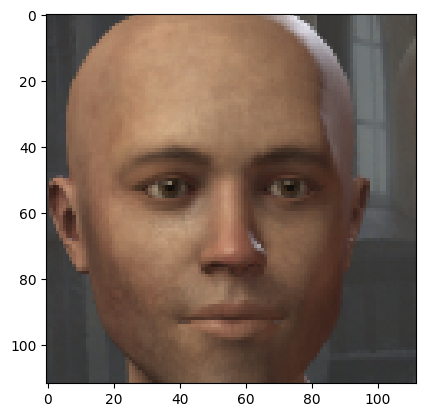

100%|██████████| 1/1 [00:00<00:00, 22.51it/s]

cosine sim tensor([-0.0434])


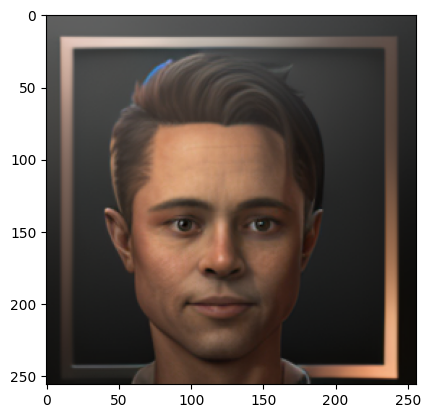

tensor([0.2766])


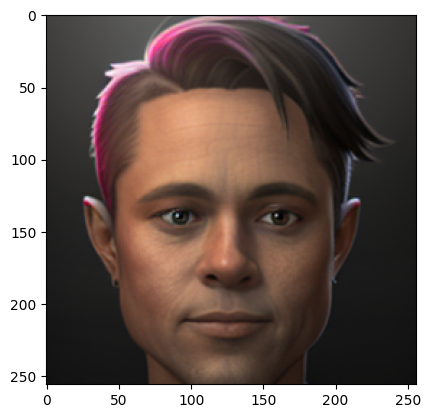

face not detected


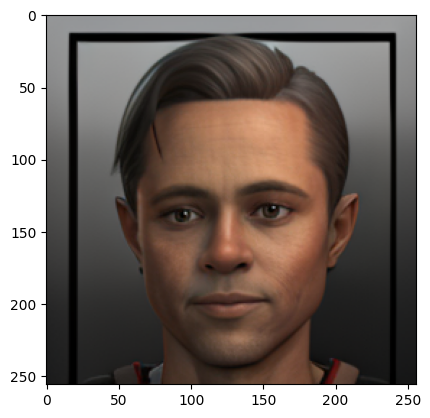

tensor([0.3400])


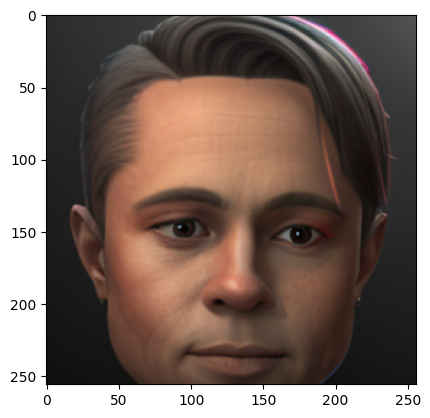

face not detected


In [20]:
medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
augmentor = IPAdapterAugmentor(ck_images_alinged=medium_geneset.alligned_images, ck_embeds=medium_geneset.model2embeddings["arcface-r100"], s_scale=.0, v2=False)
real_image = cv2.imread("../../data/real_faces_dataset/brad_pit/006_aee8d88b.jpg")
augmented = augmentor.make_real_closer_to_ck(real_image)

real_embed, real_aligned = augmentor.get_embed(real_image)
closest_image = augmentor.get_closest_ck(real_aligned)
plt.imshow(closest_image)
plt.show()
print("cosine sim", torch.nn.CosineSimilarity(dim=1, eps=1e-6)(real_embed, augmentor.get_embed_arcface_r100(closest_image)))

for image in augmented:
    plt.imshow(image)
    plt.show()
    try:
        generated_embed, _ = augmentor.get_embed(np.array(image))
        cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
        print(cos(real_embed, generated_embed))
    except Exception as e:
        print("face not detected")
    

### V2

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
100%|██████████| 1/1 [00:00<00:00, 13.54it/s]


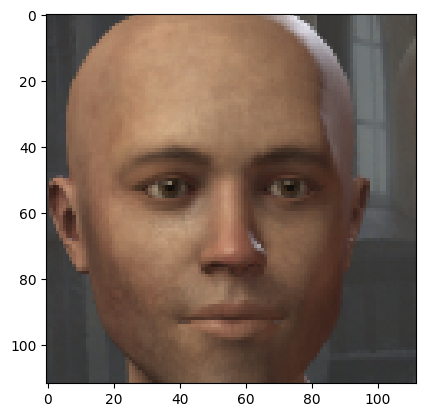

100%|██████████| 1/1 [00:00<00:00, 18.96it/s]

cosine sim tensor([-0.0434])


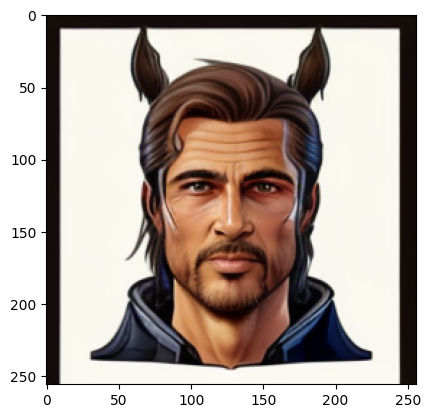

tensor([0.4480])


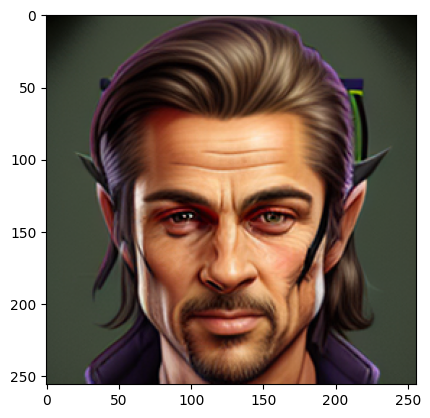

tensor([0.5291])


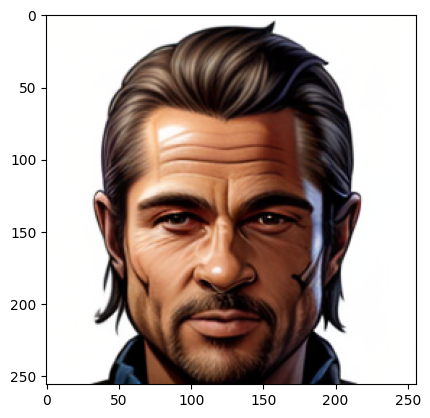

face not detected


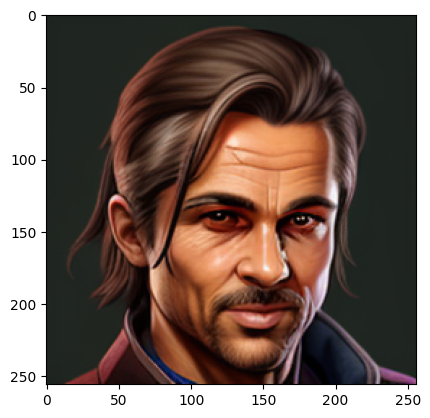

tensor([0.5238])


In [24]:
real_embed, real_aligned = augmentor.get_embed(real_image)
closest_image = augmentor.get_closest_ck(real_aligned)
plt.imshow(closest_image)
plt.show()
print("cosine sim", torch.nn.CosineSimilarity(dim=1, eps=1e-6)(real_embed, augmentor.get_embed_arcface_r100(closest_image)))

for image in augmented2:
    plt.imshow(image)
    plt.show()
    try:
        generated_embed, _ = augmentor.get_embed(np.array(image))
        cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
        print(cos(real_embed, generated_embed))
    except Exception as e:
        print("face not detected")

### V2 - s_scale 

100%|██████████| 1/1 [00:00<00:00, 23.33it/s]


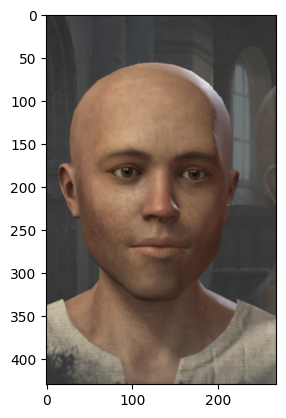

100%|██████████| 1/1 [00:00<00:00, 20.71it/s]

cosine sim tensor([-0.0636])


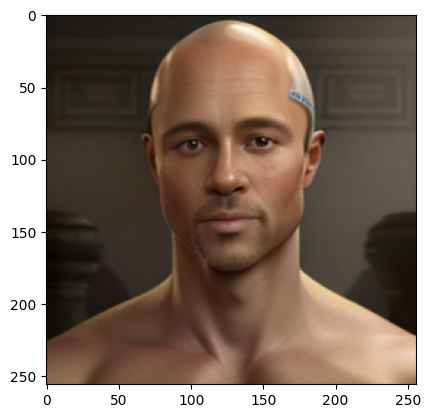

tensor([0.3214])


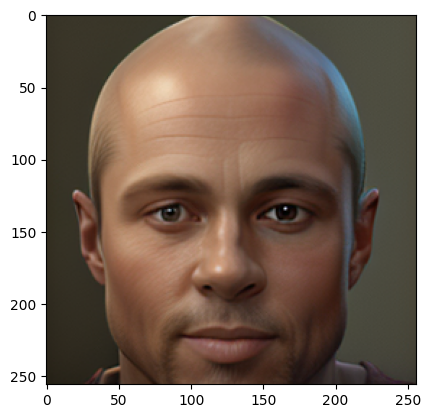

face not detected


100%|██████████| 1/1 [00:00<00:00, 20.69it/s]

cosine sim r100 tensor([0.4365])


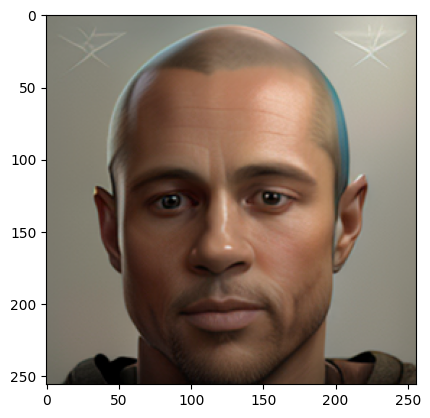

face not detected


100%|██████████| 1/1 [00:00<00:00, 23.02it/s]

cosine sim r100 tensor([0.4058])


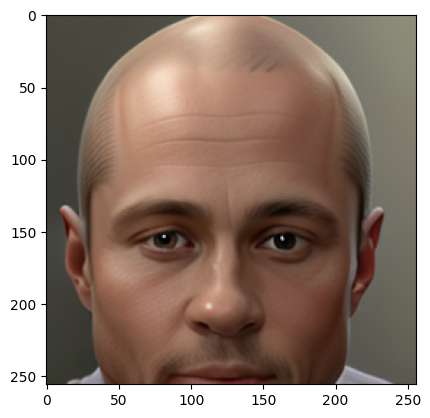

face not detected


100%|██████████| 1/1 [00:00<00:00, 22.37it/s]

cosine sim r100 tensor([-0.0203])


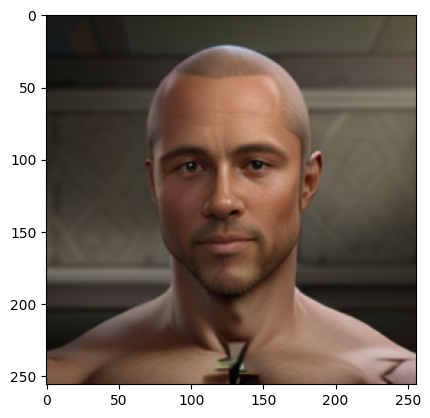

tensor([0.2699])


In [65]:
prompt = "The image is a realistic digital rendering with smooth textures and soft, natural lighting that adds depth. The subject is shown in a front-facing pose, is bald and has the entire face and part of the neck clearly visible. The background is a muted, rustic interior with a slight blur, which contrasts with the sharply focused subject. The textures are lifelike, using a naturalistic color palette with earthy tones and subtle gradients, contributing to a calm, balanced composition."
prompt2 = "The image presents a highly detailed and realistic video game avatar / digital rendering in a portrait view with smooth textures and soft, natural lighting that adds depth. The subject, a bald male, is depicted in a front-facing pose, with the entire face, neck, and collarbones clearly visible. The face is centrally positioned, occupying most of the frame, with the eyes aligned near the upper third, creating a balanced and engaging composition. The background is a muted, rustic interior with a subtle blur, contrasting with the sharply focused subject."
prompt3 = "The image presents a highly detailed and realistic video game avatar / digital rendering in a portrait view with smooth textures and soft, natural lighting that adds depth. The subject, a bald male, is depicted in a front-facing pose, with the entire face, neck, and upperchest clearly visible. The face is centrally positioned, with the eyes aligned near the upper third."
# medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
# images = np.array([np.array(Image.open(p)) for p in medium_geneset.paths[:5_000]])
# augmentor = IPAdapterAugmentor(
#     ck_images_alinged=images, 
#     ck_embeds=medium_geneset.model2embeddings["arcface-r100"], s_scale=1.5, v2=True,
#     prompt=prompt3,
#     num_samples=5,
# )
# real_image = cv2.imread("/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/brad_pit/006_aee8d88b.jpg")
# augmented = augmentor.make_real_closer_to_ck(real_image)

real_embed, real_aligned = augmentor.get_embed(real_image)
emb_r100 = augmentor.get_embed_arcface_r100(real_aligned)
closest_image = augmentor.get_closest_ck(real_aligned)
plt.imshow(closest_image)
plt.show()
print("cosine sim", torch.nn.CosineSimilarity(dim=1, eps=1e-6)(real_embed, augmentor.get_embed_arcface_r100(closest_image)))

for image in augmented:
    plt.imshow(image)
    plt.show()
    try:
        generated_embed, _ = augmentor.get_embed(np.array(image))
        cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
        print(cos(real_embed, generated_embed))
    except Exception as e:
        print("face not detected")
        emb_g_r100 = augmentor.get_embed_arcface_r100(np.array(image))
        print("cosine sim r100", torch.nn.CosineSimilarity(dim=1, eps=1e-6)(emb_r100, emb_g_r100))
        

In [66]:
celeba_dataset = ProcessedDataset(DATA_DIR / "celeba_sample_embeddings")
celeba_dataset.paths[:5]

100%|██████████| 7/7 [00:00<00:00, 242.97it/s]


array(['/Users/czyjtu/Downloads/archive/img_align_celeba/img_align_celeba/000026.jpg',
       '/Users/czyjtu/Downloads/archive/img_align_celeba/img_align_celeba/000027.jpg',
       '/Users/czyjtu/Downloads/archive/img_align_celeba/img_align_celeba/000032.jpg',
       '/Users/czyjtu/Downloads/archive/img_align_celeba/img_align_celeba/000033.jpg',
       '/Users/czyjtu/Downloads/archive/img_align_celeba/img_align_celeba/000146.jpg'],
      dtype='<U76')

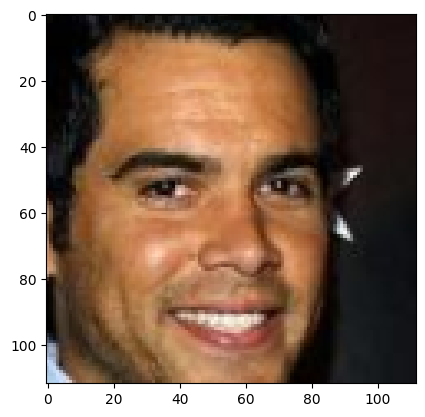

In [68]:
plt.imshow(celeba_dataset.alligned_images[12])

In [93]:
def make_images_closer_to_ck(images, ck_images_paths, ck_embeds, checkpoint_path: Path = None):
    prompt = "The image presents a highly detailed and realistic video game avatar / digital rendering in a portrait view with smooth textures and soft, natural lighting that adds depth. The subject, a bald male, is depicted in a front-facing pose, with the entire face, neck, and upperchest clearly visible. The face is centrally positioned, with the eyes aligned near the upper third."
    augmentor = IPAdapterAugmentor(
        ck_images_alinged=ck_images_paths, 
        ck_embeds=ck_embeds, s_scale=1.3, v2=True,
        prompt=prompt,
        num_samples=5,
    )
    if checkpoint_path is not None:
        checkpoint_path.resolve().parent.mkdir(exist_ok=True, parents=True)

    augmented_images = []
    for i, image in tqdm(list(enumerate(images))):
        if i % 20 == 1 and checkpoint_path is not None:
            np.save(checkpoint_path / f"checkpoint_{i}", np.array(augmented_images))
        augmented = augmentor.make_real_closer_to_ck(image)
        augmented_images.append(augmented)
    return np.array(augmented_images)

celeba_dataset = ProcessedDataset(DATA_DIR / "celeba_sample_embeddings")
celeba_attrs = pd.read_csv("/Users/czyjtu/Downloads/archive/list_attr_celeba.csv")
# select 200 images of male 
male_paths = [p for p in celeba_dataset.paths if celeba_attrs.loc[celeba_attrs["image_id"] == Path(p).name]["Male"].values[0] == 1][:200]
print(len(male_paths))
celeba_images = np.array([np.array(Image.open(p)) for p in male_paths])

100%|██████████| 7/7 [00:00<00:00, 242.71it/s]


200


## Generate celeba augmented images 

In [ ]:
medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
out_dir = DATA_DIR / "celeba_ck_images"
out_dir.mkdir(exist_ok=True)
np.save(out_dir / "celeba_images", celeba_images)
celeba_ck_images = make_images_closer_to_ck(celeba_images, medium_geneset.paths, medium_geneset.model2embeddings["arcface-r100"], checkpoint_path=out_dir)
np.save(out_dir / "celeba_ck_images", celeba_ck_images)

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  5.64it/s]
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
100%|██████████| 1/1 [00:00<00:00, 24.43it/s]


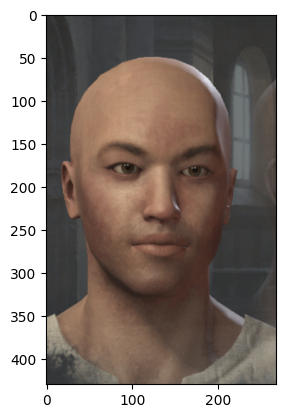

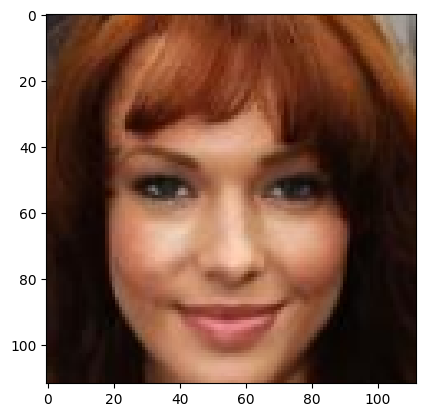

100%|██████████| 1/1 [00:00<00:00, 19.57it/s]


cosine sim tensor([-0.0172])


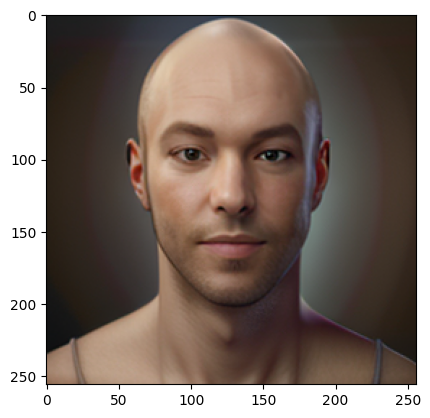

tensor([0.3895])


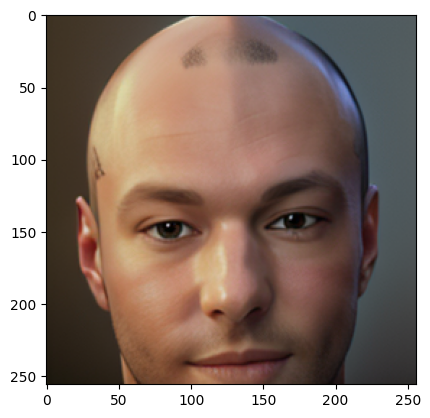

face not detected


100%|██████████| 1/1 [00:00<00:00, 22.98it/s]

cosine sim r100 tensor([0.0550])


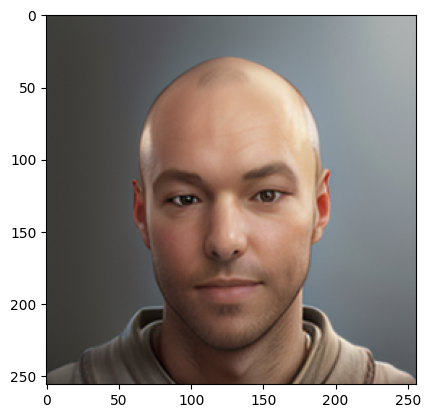

tensor([0.4877])


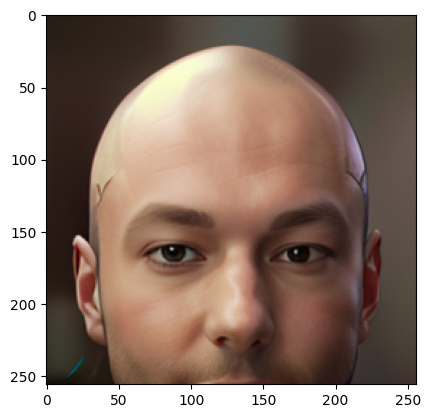

face not detected


100%|██████████| 1/1 [00:00<00:00, 20.97it/s]

cosine sim r100 tensor([-0.1133])


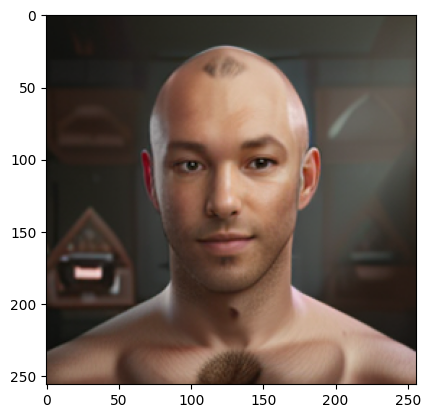

tensor([0.3440])


In [77]:
prompt3 = "The image presents a highly detailed and realistic video game avatar / digital rendering in a portrait view with smooth textures and soft, natural lighting that adds depth. The subject, a bald person, is depicted in a front-facing pose, with the entire face, neck, and upperchest clearly visible. The face is centrally positioned, with the eyes aligned near the upper third."
medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
images = medium_geneset.paths
augmentor = IPAdapterAugmentor(
    ck_images_alinged=images, 
    ck_embeds=medium_geneset.model2embeddings["arcface-r100"], s_scale=1, v2=True,
    prompt=prompt3,
    num_samples=5,
)
real_image = np.array(Image.open(celeba_dataset.paths[22]))
augmented_celeba = augmentor.make_real_closer_to_ck(real_image)

real_embed, real_aligned = augmentor.get_embed(real_image)
emb_r100 = augmentor.get_embed_arcface_r100(real_aligned)
closest_image = augmentor.get_closest_ck(real_aligned)
plt.imshow(closest_image)
plt.show()
plt.imshow(real_aligned)
plt.show()
print("cosine sim", torch.nn.CosineSimilarity(dim=1, eps=1e-6)(real_embed, augmentor.get_embed_arcface_r100(closest_image)))

for image in augmented_celeba:
    plt.imshow(image)
    plt.show()
    try:
        generated_embed, _ = augmentor.get_embed(np.array(image))
        cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
        print(cos(real_embed, generated_embed))
    except Exception as e:
        print("face not detected")
        emb_g_r100 = augmentor.get_embed_arcface_r100(np.array(image))
        print("cosine sim r100", torch.nn.CosineSimilarity(dim=1, eps=1e-6)(emb_r100, emb_g_r100))

# Brudnopis 

## Portrait 

In [45]:

import cv2
from insightface.app import FaceAnalysis
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))


images = [real_image]

faceid_embeds = []
for image in images:
    faces = app.get(image)
    faceid_embeds.append(torch.from_numpy(faces[0].normed_embedding).unsqueeze(0).unsqueeze(0))
faceid_embeds = torch.cat(faceid_embeds, dim=1)

import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image

from thirdparty.ip_adapter.ip_adapter_faceid_separate import IPAdapterFaceID

base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
ip_ckpt = "ip-adapter-faceid-portrait_sd15.bin"
device = "cpu"
repo_id = "h94/IP-Adapter-FaceID"

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)
vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float32)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float32,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None
)


# load ip-adapter
ckpt_path = hf_hub_download(repo_id=repo_id, filename=ip_ckpt)
ip_model = IPAdapterFaceID(pipe, ckpt_path, device, num_tokens=16, n_cond=5, torch_dtype=torch.float32)

# generate image
prompt = "photo of a woman in red dress in a garden"
negative_prompt = "monochrome, lowres, bad anatomy, worst quality, low quality, blurry"

images = ip_model.generate(
    prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds, num_samples=4, width=256, height=256, num_inference_steps=30, seed=2023
)



Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

100%|██████████| 30/30 [13:21<00:00, 26.72s/it]


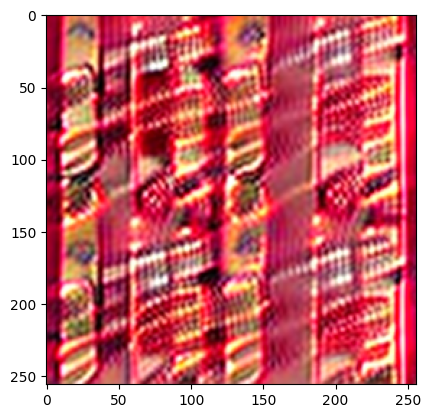

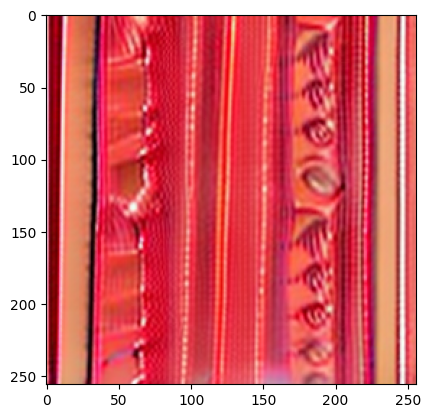

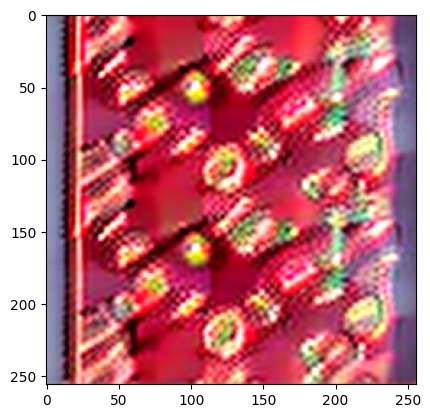

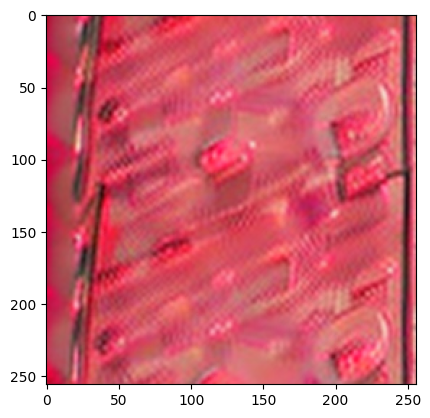

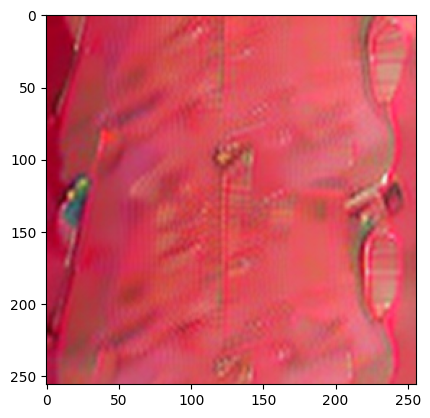

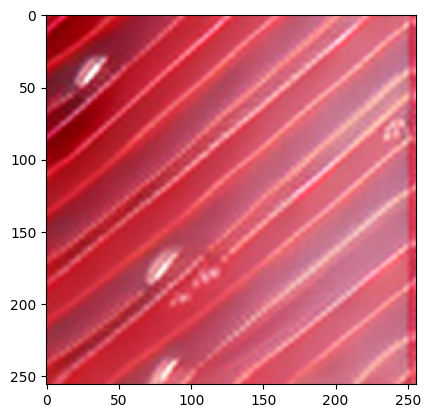

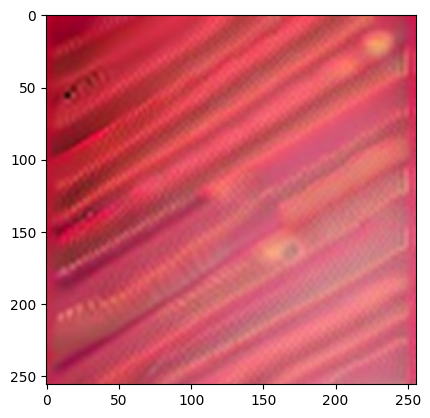

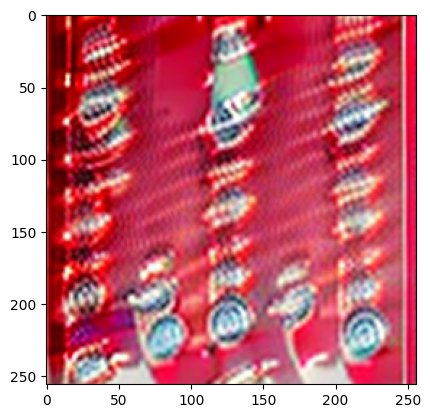

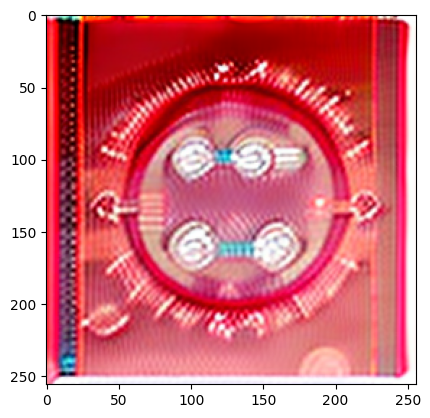

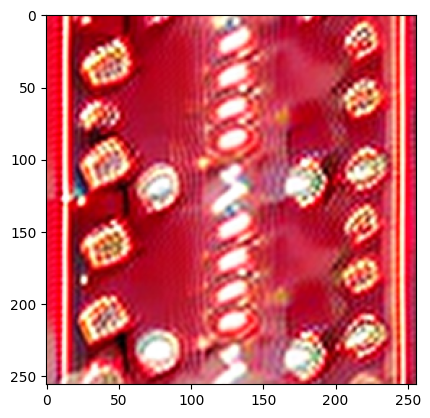

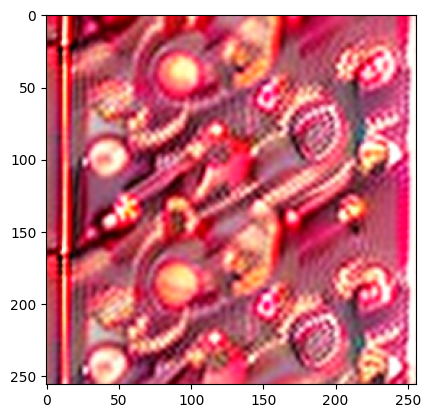

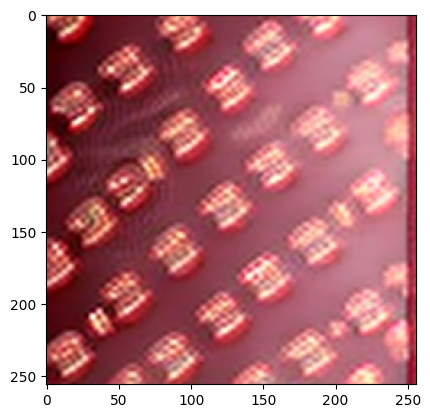

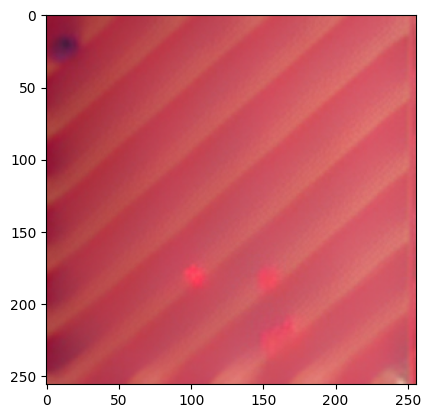

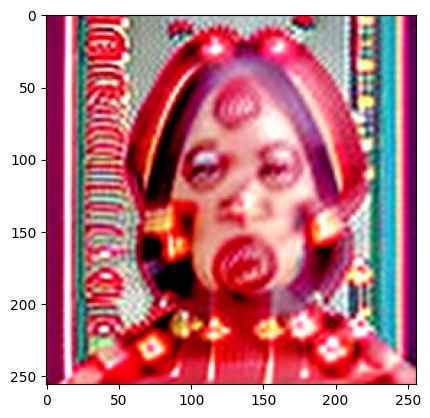

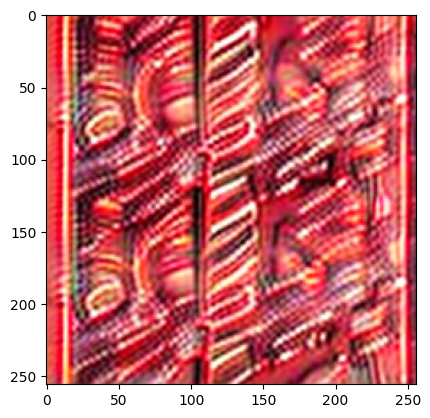

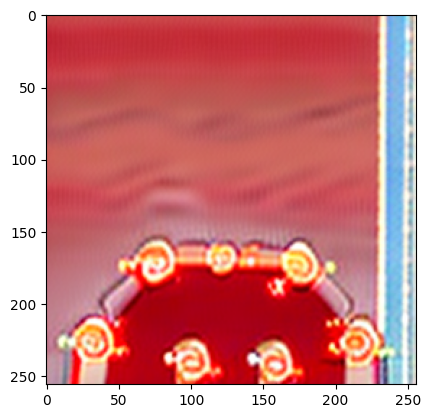

In [46]:
for image in images:
    plt.imshow(image)
    plt.show()

In [36]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image
import cv2
from insightface.app import FaceAnalysis
import torch
from thirdparty.ip_adapter.ip_adapter_faceid import IPAdapterFaceID

class IPAdapterPortraitEmbedder:
    def __init__(
        self,
        base_model_path: str = "SG161222/Realistic_Vision_V4.0_noVAE",
        vae_model_path: str = "stabilityai/sd-vae-ft-mse",
        prompt = "",
        negative_prompt = "",    
        device = "cpu",
        width = 256,
        height = 256,
        num_samples = 4,
        num_inference_steps = 30,
        seed = 2023,
        repo_id = "h94/IP-Adapter-FaceID"
    ):
        self.noise_scheduler = DDIMScheduler(
            num_train_timesteps=1000,
            beta_start=0.00085,
            beta_end=0.012,
            beta_schedule="scaled_linear",
            clip_sample=False,
            set_alpha_to_one=False,
            steps_offset=1,
        )
        self.vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float32)
        self.pipe = StableDiffusionPipeline.from_pretrained(
            base_model_path,
            torch_dtype=torch.float32,
            scheduler=self.noise_scheduler,
            vae=self.vae,
            feature_extractor=None,
            safety_checker=None
        )
        ip_ckpt = "ip-adapter-faceid-portrait_sd15.bin"
        ckpt_path = hf_hub_download(repo_id=repo_id, filename=ip_ckpt)
        self.ip_model = IPAdapterFaceID(self.pipe, ckpt_path, device, num_tokens=16, torch_dtype=torch.float32)
        self.prompt = prompt
        self.negative_prompt = negative_prompt
        self.width = width
        self.height = height
        self.num_samples = num_samples
        self.num_inference_steps = num_inference_steps
        self.seed = seed

        self.app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.app.prepare(ctx_id=0)


    def make_real_closer_to_ck(self, real_images: list[np.ndarray]) -> np.ndarray:
        faceid_embeds = []
        for image in real_images:
            faces = self.app.get(image)
            faceid_embeds.append(torch.from_numpy(faces[0].normed_embedding).unsqueeze(0).unsqueeze(0))

        # images = ip_model.generate(
        #     prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds, num_samples=4, width=512, height=512, num_inference_steps=30, seed=2023
        # )
        images = self.ip_model.generate(
            prompt=self.prompt, negative_prompt=self.negative_prompt, faceid_embeds=faceid_embeds, num_samples=self.num_samples, 
            width=self.width, height=self.height, num_inference_steps=self.num_inference_steps, seed=self.seed
        )
        return images 
    
embeder_portrait = IPAdapterPortraitEmbedder(
    prompt = prompt,
    negative_prompt="side view, hairy, anime, covered face",
)
portraits = embeder_portrait.make_real_closer_to_ck([real_image])

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 14.12it/s]
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)


RuntimeError: Error(s) in loading state_dict for ModuleList:
	Missing key(s) in state_dict: "0.to_q_lora.down.weight", "0.to_q_lora.up.weight", "0.to_k_lora.down.weight", "0.to_k_lora.up.weight", "0.to_v_lora.down.weight", "0.to_v_lora.up.weight", "0.to_out_lora.down.weight", "0.to_out_lora.up.weight", "1.to_q_lora.down.weight", "1.to_q_lora.up.weight", "1.to_k_lora.down.weight", "1.to_k_lora.up.weight", "1.to_v_lora.down.weight", "1.to_v_lora.up.weight", "1.to_out_lora.down.weight", "1.to_out_lora.up.weight", "2.to_q_lora.down.weight", "2.to_q_lora.up.weight", "2.to_k_lora.down.weight", "2.to_k_lora.up.weight", "2.to_v_lora.down.weight", "2.to_v_lora.up.weight", "2.to_out_lora.down.weight", "2.to_out_lora.up.weight", "3.to_q_lora.down.weight", "3.to_q_lora.up.weight", "3.to_k_lora.down.weight", "3.to_k_lora.up.weight", "3.to_v_lora.down.weight", "3.to_v_lora.up.weight", "3.to_out_lora.down.weight", "3.to_out_lora.up.weight", "4.to_q_lora.down.weight", "4.to_q_lora.up.weight", "4.to_k_

#### Other

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/glintr100.onnx recognition
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


100%|██████████| 1/1 [00:00<00:00, 14.13it/s]


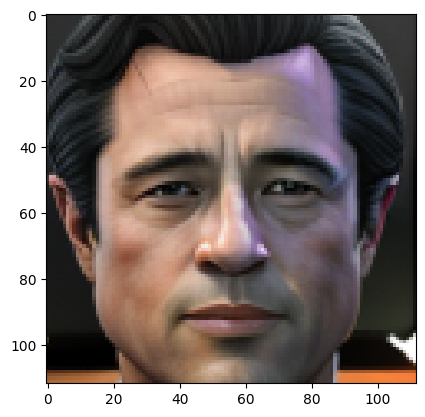

(4, 13)
-0.051189613 0.6597408


100%|██████████| 6/6 [00:00<00:00, 192.93it/s]


In [54]:
import torch
from torch import nn
import pytorch_lightning as pl
from torch.nn import functional as F
from sklearn.preprocessing import normalize


class DNARegressor(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressor, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        x = self.layers[-1](x)
        return x
    

class MLP(pl.LightningModule):
    def __init__(self, model: nn.Module):
        super(MLP, self).__init__()
        self.model = model 
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("test_loss", loss, on_epoch=True, prog_bar=True)
        return loss
import torch as th 

mlp = MLP.load_from_checkpoint("../../experiments/easy_geneset_embeddings/mlp_model.ckpt")
mlp.eval()
mlp.to("cpu")

arcface_model = load_insightface_model("../../thirdparty/recognition/weights/arcface_r100.pth")
allinged_images, _ = allign_faces(np.array(images), FaceDetector(), [""] * len(images), None)
embed_generated = normalize(get_embeddings(allinged_images, arcface_model))

plt.imshow(allinged_images[0])
plt.show()
pred = mlp.forward(th.tensor(embed_generated).float()).detach().numpy()
print(pred.shape)
print(pred.min(), pred.max())

X_train_sc, X_val_sc, X_test_sc, Y_train, Y_val, Y_test, train_images, val_images, test_images, scaler_x = load_geneset_dataset(GENESET)
save_predicitons(pred, scaler_x, Path("./dna_brad_pit_augmented"), GENESET) 